# Does "AdaptiveRSI" beat plain old 70/30? 📏🪞
### A length-aware RSI framework, tested honestly, in plain English

Here's the pitch, from a slick TradingView write-up (and a free 38-page *"RSI Manifesto"*): the classic RSI overbought/oversold lines at **70 and 30** are *length-naive*. RSI(2) at 70 and RSI(200) at 70 are not the same event — so instead of two fixed numbers, you should define your levels as **standardized σ landmarks** in a transformed RSI space, then translate them back into the right RSI value for each length. Do that and, the story goes, you read the market's "RSI environment" far more consistently.

The motivation is genuinely correct — one threshold for every length *is* naive. But the fix is sold as something deeper than it is. Underneath the σ vocabulary, the transform is a **monotone relabel**: for any fixed length it just renames a plain constant RSI level. We'll show that it cannot move a single trade, that the famous cheat-sheet is pure arithmetic, and that the only place the machinery does anything — comparing horizons — it does for free with raw RSI.

> ⚠️ **Not investment advice.** The reproducible core runs on a **synthetic** tape where we *bake in* a small, real mean-reversion edge and a single horizon — that's on purpose: it's where our tools *should* work, which proves the code, so the real-market numbers (quoted from [`../docs/results.md`](../docs/results.md)) are a measurement, not a hope.

*Follows the desk's seven beats ([METHODOLOGY.md](../../../METHODOLOGY.md)). The rigorous version is the companion,* [`02_for_the_quants.ipynb`](02_for_the_quants.ipynb).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (sigma_sleight/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from sigma_sleight import data, rsi, signals, decompose

# Offline synthetic tape: a daily close that mean-reverts at a KNOWN rate (one ~17-bar horizon),
# so an RSI oversold-bounce strategy has a real, modest edge and the rescaling null is exact.
# The real verdict (SPY/QQQ horse race) is in ../docs/results.md via examples/verify.py.
close, truth = data.synthetic_prices(seed=15)
print(f"{truth.n_bars} synthetic bars | baked-in mean reversion kappa {truth.kappa} "
      f"(~{truth.horizon:.0f}-bar horizon)")


2520 synthetic bars | baked-in mean reversion kappa 0.06 (~17-bar horizon)


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Is fixed 70/30 really length-naive? | ✅ **Yes** — and that's the framework's good idea: a short RSI swings wildly, a long one hugs 50. |
| Does the σ-transform *add* anything within a length? | ❌ **No** — it's a monotone rename. An "adaptive zone" trades *identically* to a constant RSI level (position diff = **0**, round-trip error 1.4e-14). |
| Are the cheat-sheet levels calibrated to the market? | 🎰 **No** — pure arithmetic in the length. RSI(14)=70 ⟺ **+1.527σ**, by formula, no data. |
| Does length-aware calibration beat just picking a good number? | ⚠️ **No** — on the synthetic it *loses* to a re-optimised constant (Sharpe -0.30), because it **is** one constant among many. |

> Desk shorthand: **Signal `WEAK` · Tradability `MIRAGE` · "σ adds signal?" `RELABEL`** — earned on real SPY/QQQ (the σ-band beats 70/30 in just 1 of 6 cells); let's see why.

## 1 · The claim 📣

Two fixed lines — RSI **70** and **30** — get applied to every RSI length. The framework's complaint: that's wrong, because the *same number* means different things at different lengths. Its fix: pick a handful of **σ landmarks** (±0.66, ±1, ±√3, ±2.14), and for each length translate them back to RSI with a logit transform scaled by `√(n−1)/2`. The marketing headline is that **RSI(14) = 70 lands at exactly +1.527σ** — a clean bridge between the familiar scale and the σ map.

Let's just *look* at that transform.

RSI(14)=70 -> 1.527 sigma


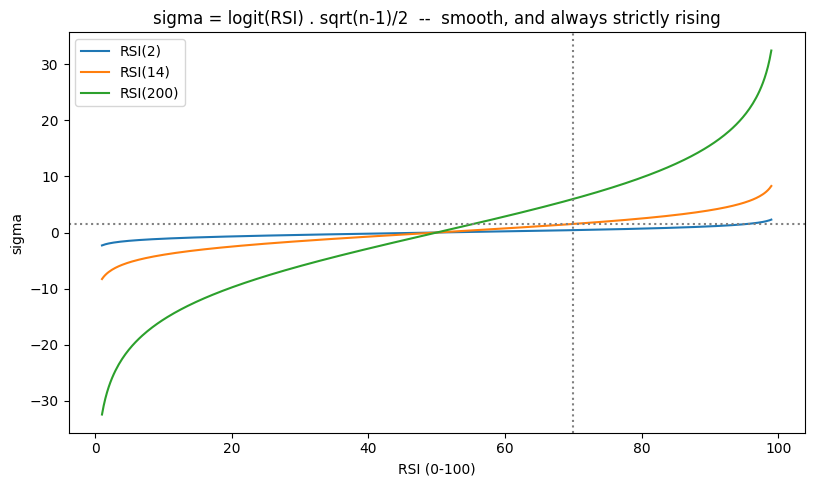

In [2]:
# The sigma<->RSI map, for three lengths. The dotted line marks RSI=70.
grid = np.linspace(1, 99, 400)
fig, ax = plt.subplots()
for n in (2, 14, 200):
    ax.plot(grid, rsi.rsi_to_sigma(grid, n), label=f'RSI({n})')
ax.axvline(70, ls=':', c='grey'); ax.axhline(rsi.rsi_to_sigma(70, 14), ls=':', c='grey')
ax.set_xlabel('RSI (0-100)'); ax.set_ylabel('sigma'); ax.legend()
ax.set_title('sigma = logit(RSI) . sqrt(n-1)/2  --  smooth, and always strictly rising')
print('RSI(14)=70 ->', round(float(rsi.rsi_to_sigma(70, 14)), 3), 'sigma')
plt.show()

Notice the one thing that decides everything: at each length the curve is **strictly rising**. A strictly rising function never crosses itself — so "σ below −1.73" and "RSI below *some fixed number*" are the **same event**. Keep that in your pocket.

## 2 · So what? 💰

If σ-zones genuinely read overbought/oversold better than 70/30, the payoff is real: the textbook RSI **mean-reversion** trade (buy when oversold, sell back at the middle) would get sharper entries at every length, and a trader could stop hand-tuning levels per instrument. That's the promise worth checking. The flip side: if the σ map only *renames* the levels, then a beautifully-motivated framework adds a vocabulary, not an edge — and a 38-page manifesto is selling the wrapping.

## 3 · How we'd know 🔬

Four checks, decided up front:

1. **Does the σ-transform move any trade within a length?** Run the same mean-reversion strategy through a σ band and through the constant RSI band it implies. If they differ, σ matters; if the difference is **zero**, it's a relabel.
2. **Is the cheat-sheet arithmetic or calibration?** Rebuild the published zone table from the formula alone.
3. **Does σ-calibration beat just picking a good constant?** Race fixed 70/30, the σ-band, and a re-optimised constant — net of costs.
4. **Does "Rescaled RSI" carry new info?** Check whether rescaling a long RSI onto the short scale changes its predictive ranking at all.

**What would make us say "relabel":** checks 1 and 4 returning exact zeros, and check 3's σ-band failing to beat a plain constant.

## 4 · The teardown 🔧

### 4a · The "adaptive zone" is a constant in disguise
We take RSI(2), enter when the σ-transformed RSI dips below −√3 (the framework's oversold edge), exit at σ=0 (which is RSI 50), and compare to the constant RSI band that σ level maps to.

In [3]:
ident = decompose.crossing_identity(close, length=2, lower_sigma=-1.732)
print(f"adaptive -sqrt3 sigma  ==  constant RSI {ident['implied_lower_rsi']:.1f} / "
      f"{ident['implied_exit_rsi']:.0f}")
print(f"max difference in position, bar by bar: {ident['max_position_diff']:.1f}  "
      f"(identical = {ident['identical']}, {ident['n_entries']} entries)")

adaptive -sqrt3 sigma  ==  constant RSI 3.0 / 50
max difference in position, bar by bar: 0.0  (identical = True, 42 entries)


Zero. Every single bar, the "adaptive" σ-zone and a plain fixed RSI line hold the **same position**. The σ dressing changed the *number you read* (3.0 instead of 30), not the *trade you make*.

### 4b · The cheat-sheet is arithmetic, not market wisdom
The published table of zone levels per length isn't fitted to any chart — it falls out of the formula. Here it is, rebuilt, and the headline compression: the same σ landmark sits far from 50 for a short RSI and hugs 50 for a long one.

,consolidation,support_resistance,trend,overbought_oversold
length,,,,
2,78.9000,88.1000,97.0000,98.6000
5,65.9000,73.1000,85.0000,89.5000
14,59.1000,63.5000,72.3000,76.6000
50,54.7000,57.1000,62.1000,64.8000
200,52.3000,53.5000,56.1000,57.5000


RSI(14)=70 <=> 1.527 sigma  |  compresses toward 50: True


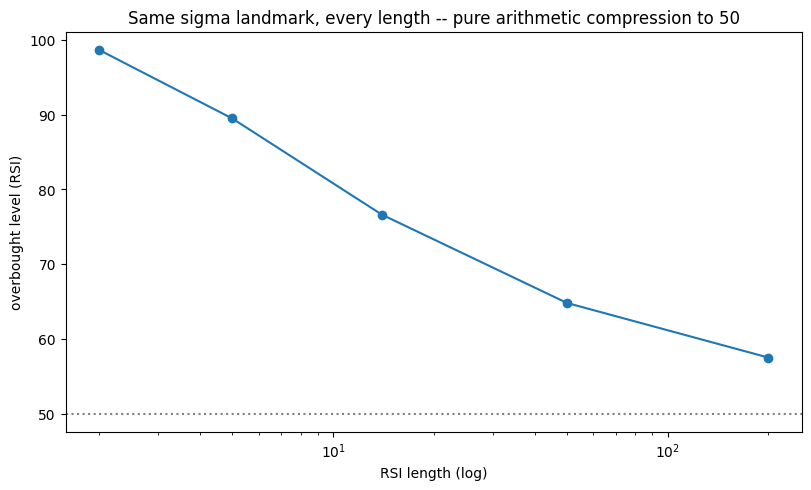

In [4]:
z = decompose.zone_arithmetic([2, 5, 14, 50, 200])
display(z['table'].round(1))
print('RSI(14)=70 <=>', round(z['sigma_at_rsi70_len14'], 3), 'sigma  |  compresses toward 50:',
      z['compresses_toward_50'])
fig, ax = plt.subplots()
ax.plot(z['table'].index, z['table']['overbought_oversold'], 'o-')
ax.axhline(50, ls=':', c='grey'); ax.set_xscale('log')
ax.set_xlabel('RSI length (log)'); ax.set_ylabel('overbought level (RSI)')
ax.set_title('Same sigma landmark, every length -- pure arithmetic compression to 50')
plt.show()

### 4c · Does the calibration actually pay?
The horse race: fixed 30/50, the σ-band (which 4a showed is a constant), and the in-sample *best* constant. On our mean-reverting tape a real edge exists — the question is whether σ-calibration captures it better than simply re-optimising a number.

In [5]:
cmp = decompose.strategy_compare(close, length=2, cost_bps=1.0)
tbl = pd.DataFrame({k: {'net/yr': v['net_ann_return'], 'Sharpe': v['sharpe'],
                        'entries': v['n_entries']}
                    for k, v in [('fixed 30/50', cmp['fixed']),
                                 ('adaptive (=const)', cmp['adaptive']),
                                 ('reopt constant', cmp['reopt'])]}).T
display(tbl.round(3))
print(f"adaptive minus re-optimised constant, in Sharpe: {cmp['adaptive_vs_reopt_sharpe']:+.2f}")
print('-> the sigma-band is just one of the constants the grid searched; it cannot win.')

,net/yr,Sharpe,entries
fixed 30/50,0.0700,0.6270,321.0000
adaptive (=const),0.0290,0.6900,42.0000
reopt constant,0.0740,0.9950,140.0000


adaptive minus re-optimised constant, in Sharpe: -0.30
-> the sigma-band is just one of the constants the grid searched; it cannot win.


### 4d · "Rescaled RSI" reads different, says the same
Rescaling RSI(70) onto the RSI(14) scale is *another* monotone relabel. So as a signal — anything based on ranking or thresholds — it is **identical** to plain RSI(70). The scatter is a straight monotone line; the predictive correlation (IC) is the same to the decimal.

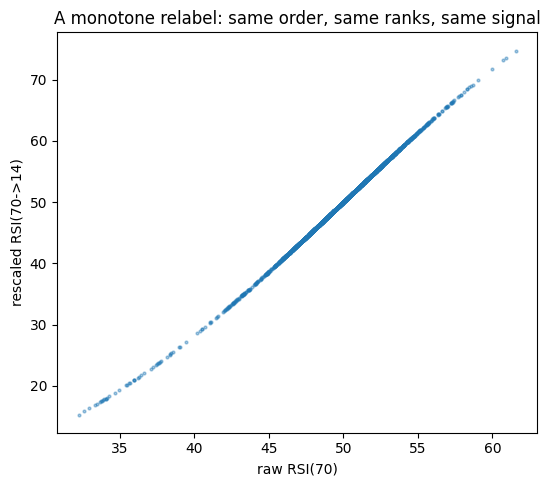

IC raw RSI(70) = -0.254   IC rescaled = -0.254   gap = +0.0e+00
the longer window DOES beat RSI(14) (partial IC -0.146) -- but that's in raw RSI(70) already; rescaling adds none of it.


In [6]:
out = decompose.rescale_increment(close, target_length=14, long_length=70, horizon=5)
raw70 = rsi.wilder_rsi(close, 70); resc = rsi.rescaled_rsi(close, 70, 14)
v = raw70.notna() & resc.notna()
fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.scatter(raw70[v], resc[v], s=4, alpha=.4)
ax.set_xlabel('raw RSI(70)'); ax.set_ylabel('rescaled RSI(70->14)')
ax.set_title('A monotone relabel: same order, same ranks, same signal')
plt.show()
print(f"IC raw RSI(70) = {out['ic_native_long']:+.3f}   IC rescaled = {out['ic_rescaled_long']:+.3f}"
      f"   gap = {out['rescale_ic_gap']:+.1e}")
print(f"the longer window DOES beat RSI(14) (partial IC {out['incremental_ic_window_over_native']:+.3f})"
      " -- but that's in raw RSI(70) already; rescaling adds none of it.")

## 5 · The verdict 🧾

- **The good idea is real**: fixed 70/30 *is* length-naive, and a length-matched level is more sensible. The framework deserves credit for naming that clearly.
- **The σ-transform adds no signal**: within a length it's a monotone rename (trade difference = 0). The cheat-sheet is arithmetic (RSI(14)=70 ⟺ +1.527σ, no data). Rescaling is rank-identical to the raw long RSI.
- **The calibration doesn't pay**: on the synthetic the σ-band *loses* to a re-optimised constant (Sharpe -0.30), because it is one constant among many.

> **Signal `WEAK`** — the only genuine content (length-matched thresholds) is a re-statement of a known fact, not a new edge. **"σ adds signal?" `RELABEL`** — the transform is order-preserving, so it moves nothing. The real-tape horse race in [`../docs/results.md`](../docs/results.md) settles whether the σ-implied band even beats naive 70/30.

## 6 · Could you trade it? 💸

Even granting the framework its best case — that the σ-implied per-length band beats 70/30 on the real tape — you'd be trading a daily RSI mean-reversion rule. That means frequent round-trips, each paying an equity spread, to harvest a few points of directional tilt. And the framework's *own* hedge is that its zones are **"not buy/sell signals"** — a description of environment, not an entry. So the honest read: the apparatus is a better *vocabulary* for thinking about length-aware thresholds, and nothing here creates an edge the σ-transform can take credit for. Tradability: a strong **`MIRAGE`** candidate.

## 7 · Going further 🚪

- **Make σ actually adaptive.** The framework invokes Cardwell-style *regimes* but its zones depend only on length. A genuinely adaptive version would let the σ bands widen with realised volatility — *that* could move trades. Fork it and test.
- **Run the real horse race across more lengths and tickers.** Does the σ-implied band beat 70/30 anywhere, after a White Reality Check on the re-optimisation? (`examples/verify.py`).
- **Multi-horizon rescaling.** On a tape with two genuine cycles, does combining raw RSI(short) *and* raw RSI(long) beat either — and does rescaling ever help over just using both raw? (It shouldn't, but it's the strongest version of the pitch.)

PRs welcome — challenge the relabel claim, or find the length/ticker where σ-zones earn their keep.